<a href="https://colab.research.google.com/github/em2tech/Machine_Learning_SJU/blob/main/HW2/data_prep_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

sns.set_style("whitegrid")

In [2]:

df = pd.read_csv('cybersecurity_intrusion_data.csv')
df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [3]:
print(df.info())
print(df.describe)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB
None
<bound method NDFrame.describe of      session_id  network_packet_size protocol_type  login_attempts  \
0     SID_00001                  599           TCP               4   


In [9]:
print(df[df['session_duration'].isnull()].shape[0], "rows have a missing session_duration")

0 rows have a missing session_duration


In [12]:
target = 'attack_detected'

numeric_cols = df.drop(columns=[target]).select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.drop(columns=[target]).select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access']
Categorical columns: ['protocol_type', 'encryption_used', 'browser_type']


In [15]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

full_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

In [16]:
X = df.drop(columns=[target])
X_processed = full_pipeline.fit_transform(X)
print("Processed feature matrix shape:", X_processed.shape)

Processed feature matrix shape: (9537, 16)


<Axes: >

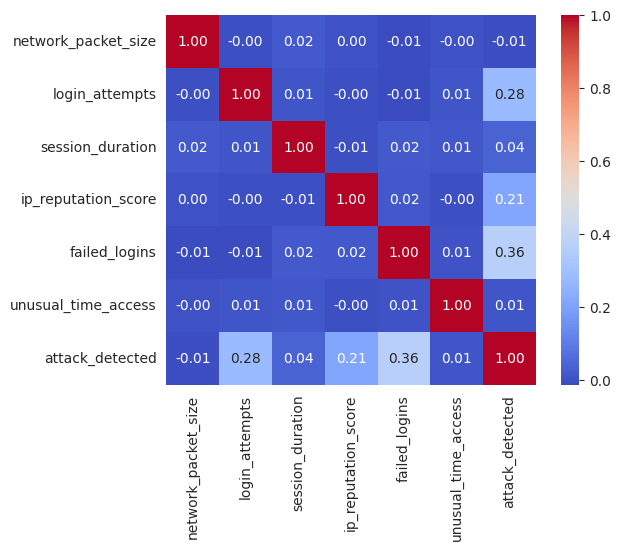

In [17]:
corr_matrix = df[numeric_cols + [target]].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)

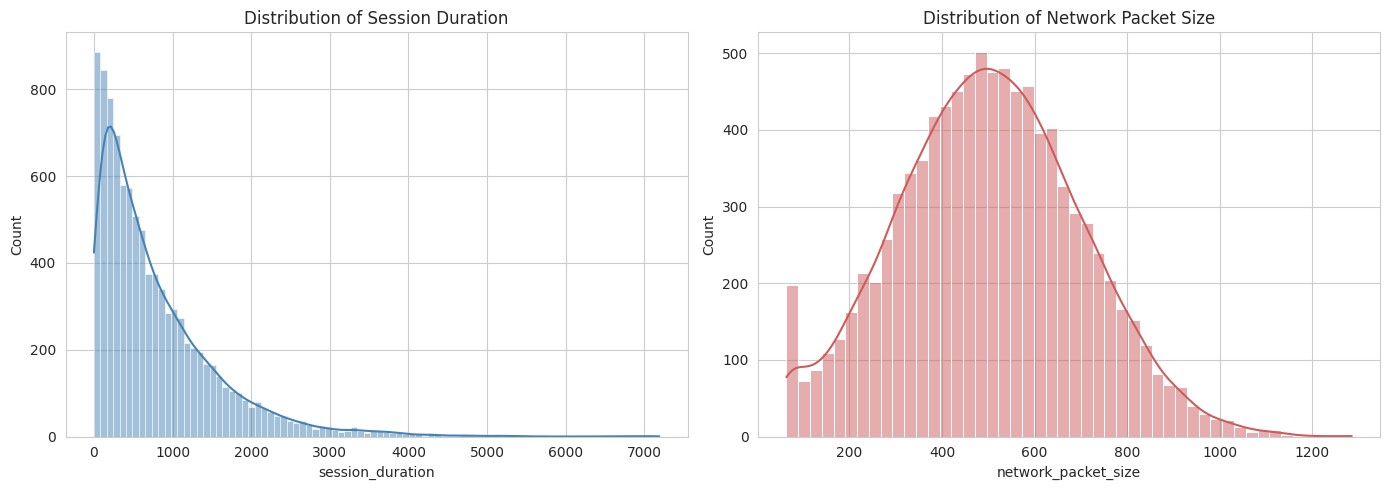

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['session_duration'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Distribution of Session Duration")

sns.histplot(df['network_packet_size'], kde=True, ax=axes[1], color='indianred')
axes[1].set_title("Distribution of Network Packet Size")

plt.tight_layout()
plt.show()

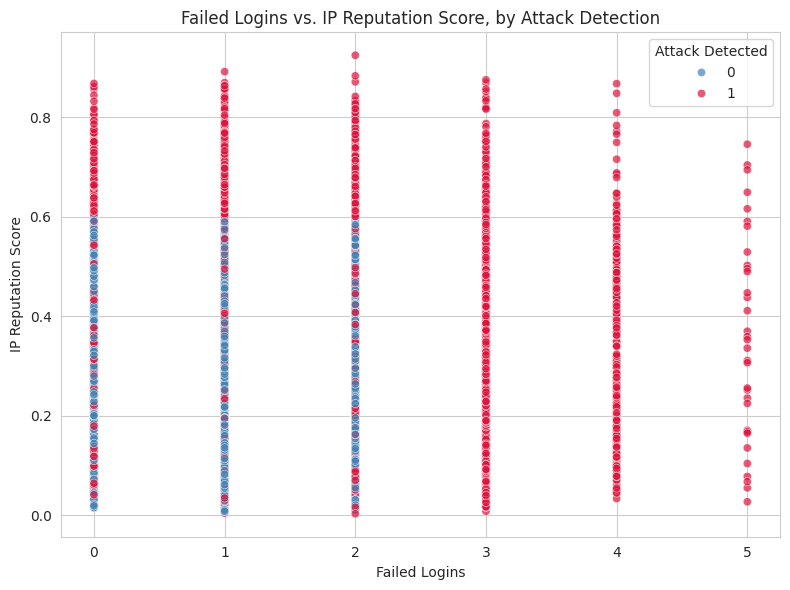

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='failed_logins', y='ip_reputation_score',
                 hue=target, palette={0: 'steelblue', 1: 'crimson'}, alpha=0.7)
plt.title("Failed Logins vs. IP Reputation Score, by Attack Detection")
plt.xlabel("Failed Logins")
plt.ylabel("IP Reputation Score")
plt.legend(title="Attack Detected")
plt.tight_layout()
plt.show()